In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("disoccupazione.csv")

In [3]:
df.head()

,iso_code,country,sex,age,year,obs_value
0,AFG,Afghanistan,Total,15+,2025,13.351
1,AFG,Afghanistan,Total,15-24,2025,16.785
2,AFG,Afghanistan,Total,25+,2025,11.340
3,AFG,Afghanistan,Male,15+,2025,12.503
4,AFG,Afghanistan,Male,15-24,2025,15.814


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57519 entries, 0 to 57518
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   iso_code   57519 non-null  object 
 1   country    57519 non-null  object 
 2   sex        57519 non-null  object 
 3   age        57519 non-null  object 
 4   year       57519 non-null  int64  
 5   obs_value  57519 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 2.6+ MB


In [9]:
df.columns

Index(['iso_code', 'country', 'sex', 'age', 'year', 'obs_value'], dtype='object')

In [10]:
df.isnull().sum()

iso_code     0
country      0
sex          0
age          0
year         0
obs_value    0
dtype: int64

In [14]:
df[df["country"].duplicated(keep="first")]

,iso_code,country,sex,age,year,obs_value
1,AFG,Afghanistan,Total,15-24,2025,16.785
2,AFG,Afghanistan,Total,25+,2025,11.340
3,AFG,Afghanistan,Male,15+,2025,12.503
4,AFG,Afghanistan,Male,15-24,2025,15.814
5,AFG,Afghanistan,Male,25+,2025,10.594
...,...,...,...,...,...,...
57514,ZWE,Zimbabwe,Male,15-24,1991,13.765
57515,ZWE,Zimbabwe,Male,25+,1991,2.690
57516,ZWE,Zimbabwe,Female,15+,1991,2.871
57517,ZWE,Zimbabwe,Female,15-24,1991,6.744


In [15]:
df["country"].value_counts()

country
Afghanistan             315
Paraguay                315
Mauritius               315
Malawi                  315
Malaysia                315
                       ... 
Lebanon                 297
South Sudan             297
Sudan                   288
Palestine (State of)    288
Ukraine                 279
Name: count, Length: 183, dtype: int64

In [16]:
df.isna().any()

iso_code     False
country      False
sex          False
age          False
year         False
obs_value    False
dtype: bool

In [18]:
df.dtypes

iso_code      object
country       object
sex           object
age           object
year           int64
obs_value    float64
dtype: object

In [20]:
df["age"] = df["age"].astype("category")

In [22]:

df["age"].dtype

CategoricalDtype(categories=['15+', '15-24', '25+'], ordered=False, categories_dtype=object)

In [23]:
df["age"] = pd.Categorical(
    df["age"],
    categories=['15-24', '25+', '15+'],
    ordered=True
)

In [24]:
df["age"]

0          15+
1        15-24
2          25+
3          15+
4        15-24
         ...  
57514    15-24
57515      25+
57516      15+
57517    15-24
57518      25+
Name: age, Length: 57519, dtype: category
Categories (3, object): ['15-24' < '25+' < '15+']

In [53]:
latest_year = df["year"].max()

In [60]:
df_latest = df[df["year"] == latest_year]

In [61]:
df_latest[df_latest["sex"] == "Total"]

,iso_code,country,sex,age,year,obs_value
0,AFG,Afghanistan,Total,15+,2025,13.351
1,AFG,Afghanistan,Total,15-24,2025,16.785
2,AFG,Afghanistan,Total,25+,2025,11.340
315,AGO,Angola,Total,15+,2025,14.108
316,AGO,Angola,Total,15-24,2025,27.229
...,...,...,...,...,...,...
56890,ZMB,Zambia,Total,15-24,2025,10.470
56891,ZMB,Zambia,Total,25+,2025,4.713
57204,ZWE,Zimbabwe,Total,15+,2025,9.293
57205,ZWE,Zimbabwe,Total,15-24,2025,15.548


In [65]:
country_unemp = df_latest[df_latest["sex"] == "Total"].groupby("country")["obs_value"].mean()

In [66]:
country_unemp.sort_values(ascending=False).head(1)

country
Djibouti    40.711
Name: obs_value, dtype: float64

In [67]:
country_unemp.sort_values(ascending=True).head(1)

country
Qatar    0.260667
Name: obs_value, dtype: float64

In [90]:
unemp = df.groupby("year")["obs_value"].mean()

In [92]:
unemp.sort_values()

year
1991     9.311976
2025     9.386121
2024     9.389182
2023     9.422560
2008     9.703841
2007     9.755146
1992     9.763498
2022     9.963206
2019    10.021056
2018    10.206647
2006    10.222560
1993    10.328871
1994    10.512396
2017    10.537556
1995    10.613865
1997    10.654860
1998    10.713616
2005    10.722824
2000    10.758209
2009    10.759245
1996    10.809840
2016    10.815830
2001    10.839197
1999    10.907678
2015    10.964977
2004    10.967303
2011    10.993418
2010    10.996019
2021    11.041259
2002    11.060389
2014    11.069237
2003    11.127247
2012    11.154597
2013    11.238128
2020    11.513536
Name: obs_value, dtype: float64

In [87]:
unemp.diff().sort_values(ascending=False).head()

year
2020    1.492480
2009    1.055404
1993    0.565373
1992    0.451522
2010    0.236775
Name: obs_value, dtype: float64

In [88]:
unemp.diff().sort_values().head()

year
2022   -1.078052
2023   -0.540646
2006   -0.500264
2021   -0.472277
2007   -0.467413
Name: obs_value, dtype: float64

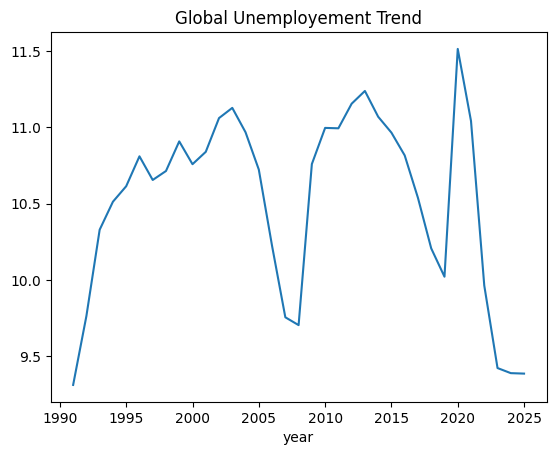

<Figure size 640x480 with 0 Axes>

In [133]:
import matplotlib.pyplot as plt

unemp.plot()
plt.title("Global Unemployement Trend")
plt.show()
plt.savefig("global Unemployment Trend.png")

In [94]:
df_pv = df.pivot_table(values="obs_value", index="country", columns="sex", aggfunc="mean")

In [108]:
df_pv.head()

sex,Female,Male,Total
country,,,
Afghanistan,13.608524,8.986333,9.654552
Albania,18.461962,19.835981,19.224276
Algeria,25.943686,20.687924,21.525343
Angola,21.730533,19.556705,20.649733
Argentina,16.198981,12.944962,14.274362


In [110]:
df_pv.sort_values(["Female", "Male"], ascending=[True, False]).mean()

sex
Female    11.749593
Male       9.586824
Total     10.266596
dtype: float64

In [109]:
df.groupby("sex")["obs_value"].mean()

sex
Female    11.736933
Male       9.577414
Total     10.256717
Name: obs_value, dtype: float64

In [111]:
df_pv["gap"] = df_pv["Female"] - df_pv["Male"]

In [123]:
top_10_gender_gap = df_pv.sort_values("gap", ascending=False).head(10)

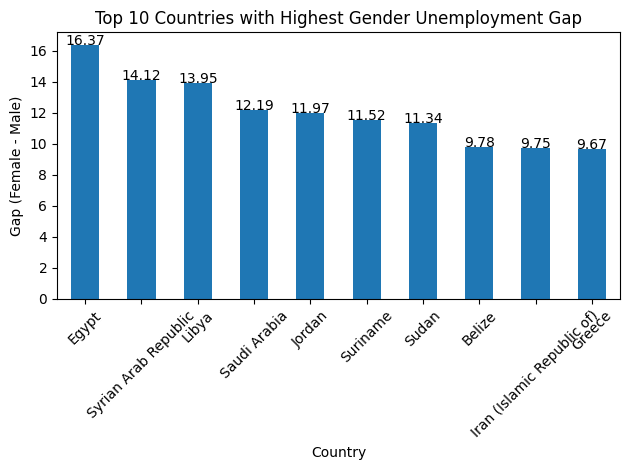

In [127]:
plt.figure()

ax = top_10_gender_gap["gap"].plot(kind="bar")

plt.title("Top 10 Countries with Highest Gender Unemployment Gap")
plt.xlabel("Country")
plt.ylabel("Gap (Female - Male)")

plt.xticks(rotation=45)

# Add value labels
for i, v in enumerate(top_10_gender_gap["gap"]):
    ax.text(i, v, round(v, 2), ha='center')

plt.tight_layout()
plt.savefig("top_10_gender_gap.png")
plt.show()

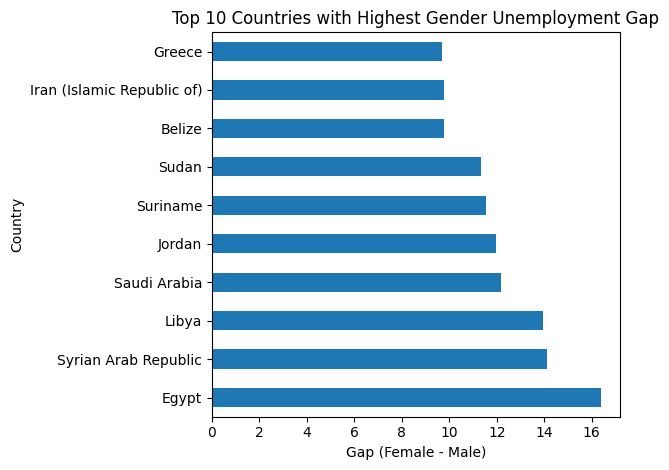

In [132]:
plt.figure()

top_10_gender_gap["gap"].plot(kind="barh")

plt.title("Top 10 Countries with Highest Gender Unemployment Gap")
plt.xlabel("Gap (Female - Male)")
plt.ylabel("Country")

plt.tight_layout()
plt.savefig("top_10_gender_gap.png")
plt.show()